In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("UberDataset.csv")



In [39]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


# DATA PRE PROSEING 

In [41]:
df['PURPOSE'].fillna('NOT', inplace=True)

In [44]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [46]:
df['START_DATE']=pd.to_datetime(df['START_DATE'],errors = 'coerce')
df['END_DATE']=pd.to_datetime(df['END_DATE'],errors = 'coerce')

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[ns]
 1   END_DATE    420 non-null    datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


In [129]:
from datetime import datetime
df['date'] = pd.to_datetime(df['START_DATE']).dt.date
df['time'] = pd.to_datetime(df['START_DATE']).dt.hour



In [131]:
df.head()

,START_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,start_date,start_time,end_date,end_time
0,2016-01-01 21:11:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,2016-01-01,21.0,2016-01-01,21.0
1,2016-01-02 01:25:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,2016-01-02,1.0,2016-01-02,1.0
2,2016-01-02 20:25:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,2016-01-02,20.0,2016-01-02,20.0
3,2016-01-05 17:31:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,2016-01-05,17.0,2016-01-05,17.0
4,2016-01-06 14:42:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,2016-01-06,14.0,2016-01-06,15.0


In [135]:
df['hour'] = pd.to_datetime(df['START_DATE']).dt.hour

df['day_night'] = pd.cut(
    x=df['hour'],
    bins=[0, 10, 15, 19, 24],
    labels=['Morning', 'Afternoon', 'Evening', 'Night']
)


In [137]:
df.head()

,START_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,start_date,start_time,end_date,end_time,hour,day_night
0,2016-01-01 21:11:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,2016-01-01,21.0,2016-01-01,21.0,21.0,Night
1,2016-01-02 01:25:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,2016-01-02,1.0,2016-01-02,1.0,1.0,Morning
2,2016-01-02 20:25:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,2016-01-02,20.0,2016-01-02,20.0,20.0,Night
3,2016-01-05 17:31:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,2016-01-05,17.0,2016-01-05,17.0,17.0,Evening
4,2016-01-06 14:42:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,2016-01-06,14.0,2016-01-06,15.0,14.0,Afternoon


In [139]:
df.dropna(inplace =True)
df.shape


(413, 14)

# data visualition

(array([   0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200')])

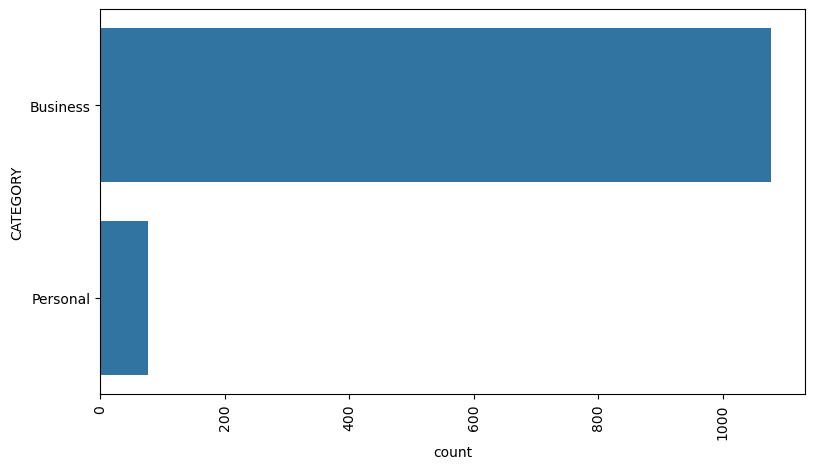

In [32]:
plt.figure(figsize=(20, 5))

# First subplot: Category counts
plt.subplot(1, 2, 1)
sns.countplot(df['CATEGORY'])
plt.xticks(rotation = 90)




<Axes: xlabel='count', ylabel='PURPOSE'>

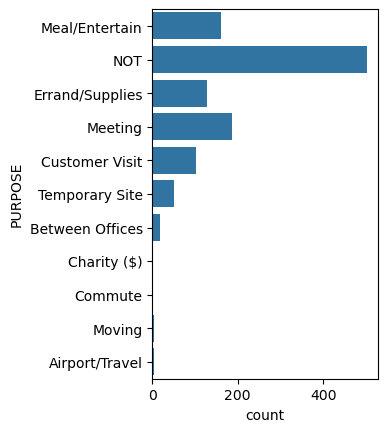

In [35]:
plt.subplot(1,2,2)
sns.countplot(df['PURPOSE'])

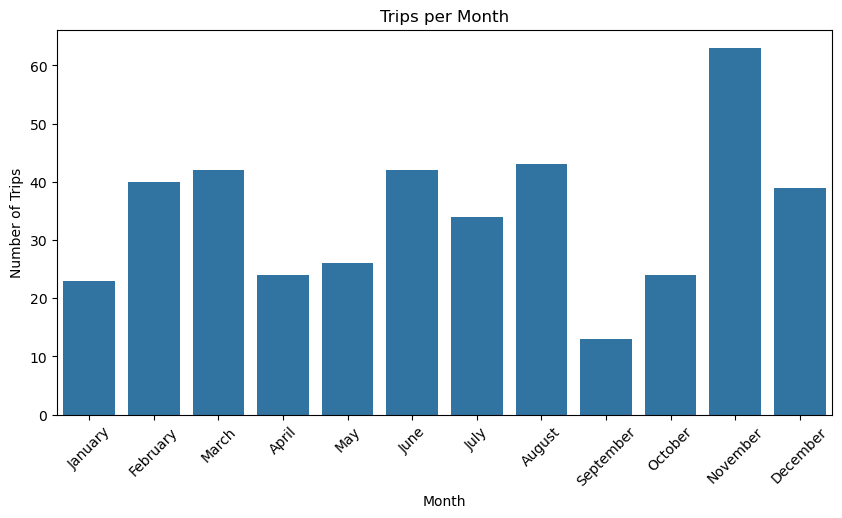

In [168]:
df['MONTH'] = pd.DatetimeIndex(df['START_DATE']).month

month_label = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df['MONTH_NAME'] = df['MONTH'].apply(lambda x: month_label[x - 1])

plt.figure(figsize=(10,5))
sns.countplot(x=df['MONTH'])
plt.xticks(ticks=range(12), labels=month_label, rotation=45)
plt.title('Trips per Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.show()


<Axes: xlabel='count', ylabel='day_night'>

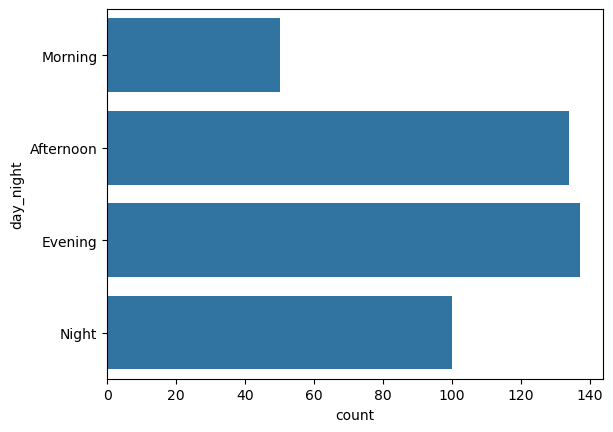

In [47]:
sns.countplot(df['day_night'])

In [57]:
# Use the correct column name: START_DATE (not start_date)
df['DAY'] = df['START_DATE'].dt.weekday

# Use proper day labels (optional: make them full or capitalized)
day_label = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

df['DAY'] = df['DAY'].map(day_label)


In [55]:
df.head


<bound method NDFrame.head of               START_DATE            END_DATE  CATEGORY             START  \
0    2016-01-01 21:11:00 2016-01-01 21:17:00  Business       Fort Pierce   
1    2016-01-02 01:25:00 2016-01-02 01:37:00  Business       Fort Pierce   
2    2016-01-02 20:25:00 2016-01-02 20:38:00  Business       Fort Pierce   
3    2016-01-05 17:31:00 2016-01-05 17:45:00  Business       Fort Pierce   
4    2016-01-06 14:42:00 2016-01-06 15:49:00  Business       Fort Pierce   
...                  ...                 ...       ...               ...   
1151                 NaT                 NaT  Business           Kar?chi   
1152                 NaT                 NaT  Business  Unknown Location   
1153                 NaT                 NaT  Business        Katunayake   
1154                 NaT                 NaT  Business           Gampaha   
1155                 NaT                 NaT       NaN               NaN   

                  STOP    MILES          PURPOSE        d

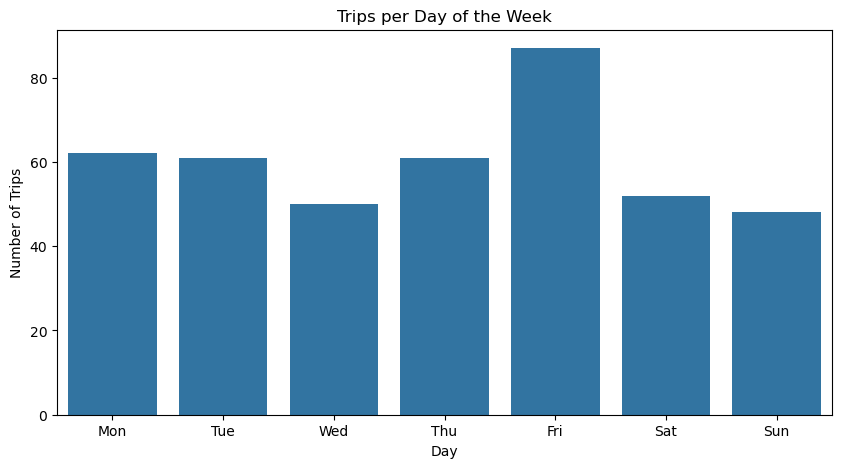

In [59]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='DAY', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Trips per Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Trips')
plt.show()


<Axes: ylabel='MILES'>

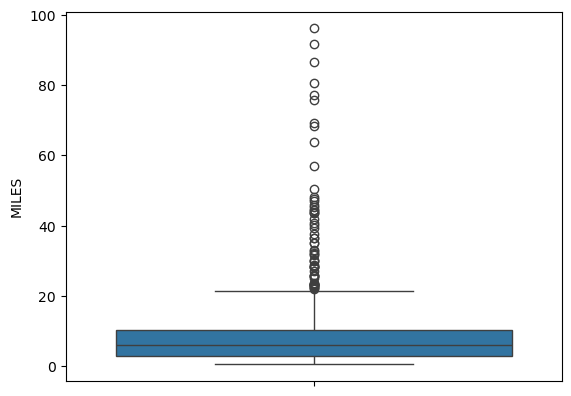

In [81]:
sns.boxplot(df[df['MILES']<100]['MILES'])

/var/folders/fg/v07qf1l558z63n7l4f5hv8yh0000gn/T/ipykernel_1428/1171915261.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['MILES']<40]['MILES'])


<Axes: xlabel='MILES', ylabel='Density'>

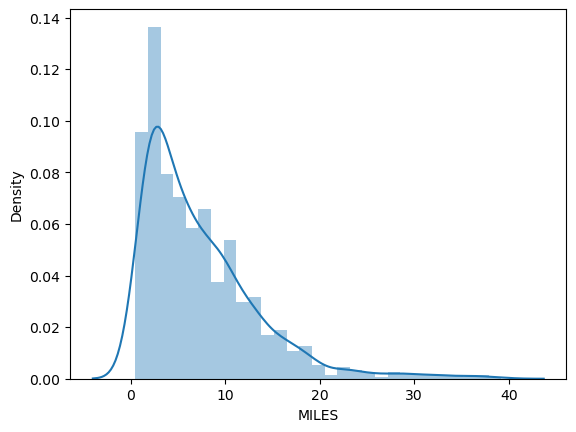

In [85]:
sns.distplot(df[df['MILES']<40]['MILES'])